In [1]:
import strawberryfields as sf
from strawberryfields.ops import *

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Fock States


In [10]:
#Initialize the engine and program with one quantum mode/system
prog_fock = sf.Program(1)

In [39]:
with prog_fock.context as q:
    Fock(8) | q[0]

In [40]:
#run the engine and get the state
eng_fock = sf.Engine("fock", backend_options={"cutoff_dim": 10})
state_fock = eng_fock.run(prog_fock).state

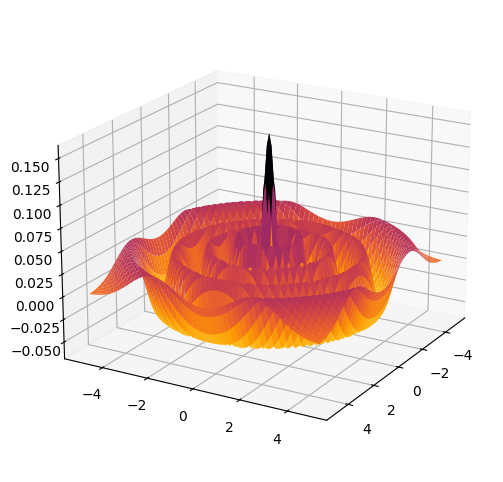

In [41]:
X = np.arange(-5, 5, 0.1)
P = np.arange(-5, 5, 0.1)
Z = state_fock.wigner(0, X, P)
X, P = np.meshgrid(X, P)
ax = plt.figure(figsize=(8, 6)).add_subplot(projection='3d')
ax.plot_surface(X, P, Z, cmap='inferno_r')
ax.view_init(elev=20, azim=30)

plt.show()

# Coherent States

The convention of the quadratures is

$$ \hat{x} = \hat{\alpha} + \hat{\alpha}^{\dagger} $$
$$ \hat{p} = (\hat{\alpha} - \hat{\alpha}^{\dagger})/i $$

Resulting in the coherent state being centered at 

$$ (2\text{Re}(\alpha), 2\text{Im}(\alpha)) $$

in the phase space, where $\alpha$ is the complex amplitude of the coherent state $\ket{a} = \hat{D}(a)\ket{0}$

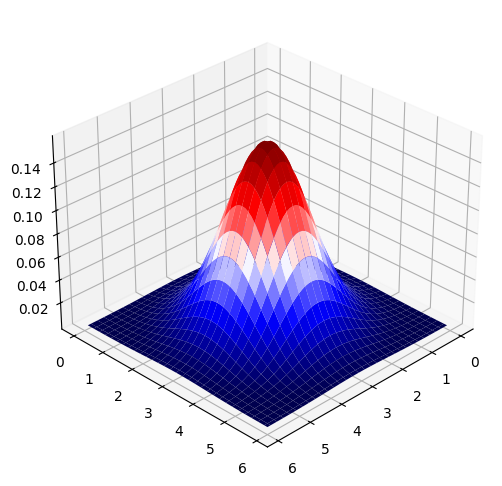

In [4]:
prog_coherent = sf.Program(1)

with prog_coherent.context as q:
    alpha = 1.5 + 1.5j
    r = np.abs(alpha)
    phi = np.angle(alpha)
    Coherent(r, phi) | q[0]

#run the engine and get the state
eng_coherent = sf.Engine("gaussian")
state_coherent = eng_coherent.run(prog_coherent).state

X = np.arange(0, 6, 0.1)
P = np.arange(0, 6, 0.1)
Z = state_coherent.wigner(0, X, P)
X, P = np.meshgrid(X, P)
ax = plt.figure(figsize=(8, 6)).add_subplot(projection='3d')
ax.plot_surface(X, P, Z, cmap='seismic')
ax.view_init(elev=30, azim=45)

plt.show()

In [5]:
type(alpha)

complex

# Squeezed States

**Note:** In `Sgate(r, phi)`, the parameter `phi` is the **phase of the squeezing operator**, not the orientation of the squeezing ellipse. The squeezed quadrature is rotated by $\theta$, which is defined as
$$ \theta = \frac{\phi}{2} $$
Therefore, to obtain squeezing along an angle $\theta$ in phase space, set $$\phi = 2*\theta$$.

In [64]:
prog_squeezed = sf.Program(1)

r = 0.75
phi = np.pi  # Radians
with prog_squeezed.context as q:
    Vac | q[0]
    Sgate(r, phi) | q[0] 

#run the engine and get the state
eng_squeezed = sf.Engine("gaussian")
state_squeezed = eng_squeezed.run(prog_squeezed).state

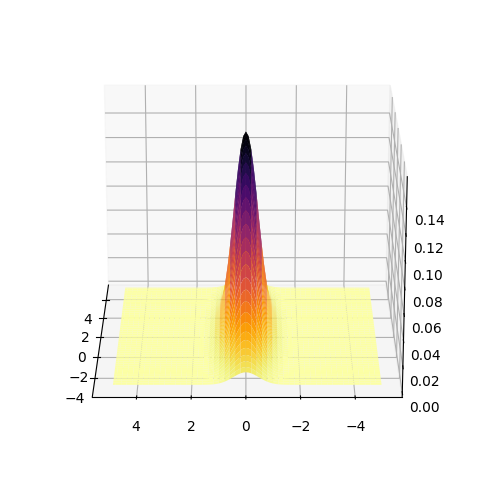

In [66]:
X = np.arange(-5, 5, 0.1)
P = np.arange(-5, 5, 0.1)
Z = state_squeezed.wigner(0, X, P)
X, P = np.meshgrid(X, P)
ax = plt.figure(figsize=(8, 6)).add_subplot(projection='3d')
ax.plot_surface(X, P, Z, cmap='inferno_r')
ax.view_init(elev=20, azim=phi/2*180/np.pi+90)  # Anti-squeezing direction
#ax.view_init(elev=20, azim=phi/2*180/np.pi)  # Squeezing direction
plt.show()

# Displaced Squeezed States

In [116]:
prog_mixed = sf.Program(1)

# Squeezing
s_r = 0.5
s_phi = 0  # Radians

# Displacement
real_a = 1
im_a = 1
d_r = np.sqrt((real_a/2)**2+(im_a/2)**2)
d_phi = np.arctan2(im_a, real_a)  # Radians

with prog_mixed.context as q:
    Vac | q[0]
    Sgate(s_r, s_phi) | q[0] 
    Dgate(d_r, d_phi) | q[0]
    

#run the engine and get the state
eng_mixed = sf.Engine("gaussian")
state_squeezed = eng_mixed.run(prog_mixed).state

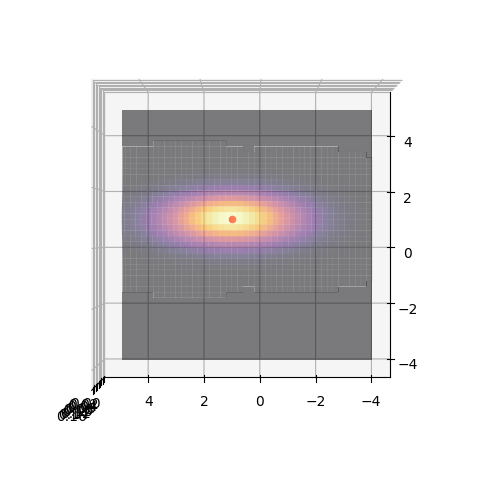

In [117]:
X = np.arange(-4, 5, 0.1)
P = np.arange(-4, 5, 0.1)
Z = state_squeezed.wigner(0, X, P)
X, P = np.meshgrid(X, P)
ax = plt.figure(figsize=(8, 6)).add_subplot(projection='3d')
ax.plot_surface(X, P, Z, cmap='inferno', alpha=0.5)
ax.scatter(1, 1, color='r')
ax.view_init(elev=90, azim=phi/2*180/np.pi+90)  # Anti-squeezing direction
#ax.view_init(elev=20, azim=phi/2*180/np.pi)  # Squeezing direction
plt.show()